# Dự đoán giá cổ phiếu FPT — HMM + ANFIS

> **Tham khảo:** Hassan et al., *"A combination of hidden Markov model and fuzzy model for stock market forecasting"*, Neurocomputing, 2009.

Notebook này triển khai pipeline kết hợp **Hidden Markov Model (HMM)** và **ANFIS** (Adaptive Neuro-Fuzzy Inference System) để dự đoán giá đóng cửa ngày tiếp theo của cổ phiếu FPT. Kết quả được so sánh với **HMM Baseline** (log-likelihood similarity) và **ANN** thuần túy.

---

## Pipeline

| Bước | Mô tả |
|------|--------|
| 1 | **HMM Training** — Học phân phối các trạng thái ẩn (market regime) bằng Baum-Welch |
| 2 | **Sliding Windows** — Mỗi cửa sổ 5 phiên → tính log-likelihood theo HMM đã học |
| 3 | **Bucketing** — Gom windows có log-likelihood gần nhau (tham số θ) thành các nhóm regime |
| 4 | **Fuzzy Rules** — Mỗi bucket → 1 rule Takagi-Sugeno với membership function Gaussian |
| 5 | **ANFIS** — Tối ưu consequence params (Weighted LSE) + premise params μ, σ (Gradient Descent) |

## Thiết kế dự đoán

```
Input window (5 phiên):  obs_t-4, ..., obs_t
        ↓  HMM log-likelihood
       l_T  →  Gaussian membership w_k  →  Σ(w_k · f_k(x)) / Σ(w_k)
                                                      ↓
                                          ŷ_return  →  close_{t+1} = close_t × (1 + ŷ)
```

**Feature vector của ngày t:** `x = [Δopen, Δhigh, Δlow, return_t, vol_ratio − 1]`  
**Consequence rule k:** `f_k(x) = p₁·Δopen + p₂·Δhigh + p₃·Δlow + p₄·return + p₅·vol_ratio + bias`

> **Lý do predict return thay vì giá tuyệt đối:** LSE trên giá tuyệt đối sẽ học `close_next ≈ close_today` (hệ số ≈ 1, bias ≈ 0) — tức là naive baseline. Predict return buộc model học *biến động* thực sự theo từng regime.

In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
print('Ready.')

Ready.


## 1. Load & Tiền xử lý

In [334]:
df = pd.read_csv('FPT.csv', parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)

df['return'] = df['close'].pct_change()
df['vol_sma20'] = df['volume'].rolling(20).mean()
df['vol_ratio'] = df['volume'] / df['vol_sma20']
df = df.dropna(subset=['return', 'vol_ratio']).reset_index(drop=True)

# Train/Test split 80/20 theo thoi gian
cut = int(len(df) * 0.8)
train_df = df.iloc[:cut].copy().reset_index(drop=True)
test_df  = df.iloc[cut:].copy().reset_index(drop=True)

print(f'Train: {len(train_df)} phien | Test: {len(test_df)} phien')
df[['time','open','high','low','close']].head(3)

Train: 1080 phien | Test: 270 phien


,time,open,high,low,close
0,2019-11-01,20.95,21.21,20.81,21.14
1,2019-11-04,21.21,21.86,21.21,21.64
2,2019-11-05,21.71,21.71,21.46,21.60


## 2. Định nghĩa HMM — Scaled Forward-Backward (Baum-Welch)

Implementation từ đầu bằng NumPy (không dùng `hmmlearn`) với **scaled forward-backward** để tránh numerical underflow khi chuỗi dài.

| Tham số | Ý nghĩa |
|---------|---------|
| `N` | Số trạng thái ẩn (market regime) |
| `M` | Số ký hiệu quan sát (sau rời rạc hóa) |
| `π` | Phân phối trạng thái ban đầu |
| `A[i,j]` | Xác suất chuyển trạng thái i → j |
| `B[i,k]` | Xác suất phát xạ ký hiệu k từ trạng thái i |

In [335]:
def discretize(df):
    r = np.where(df['return'] < -0.01, 0,
         np.where(df['return'] >  0.01, 2, 1))
    v = (df['vol_ratio'] > 1.0).astype(int).values
    return r * 2 + v

df['Obs']      = discretize(df)
train_df['Obs'] = discretize(train_df)
test_df['Obs']  = discretize(test_df)

N_OBS    = 6
N_STATES = 4

class HMM:
    """Discrete HMM voi scaled forward-backward."""
    def __init__(self, n_states, n_obs):
        self.N = n_states; self.M = n_obs
        self._init_params()

    def _init_params(self):
        self.pi = np.random.dirichlet(np.ones(self.N))
        self.A  = np.random.dirichlet(np.ones(self.N), size=self.N)
        B = np.ones((self.N, self.M)) * 0.1
        for i in range(self.N):
            B[i, i % self.M] += 2.0
        self.B = B / B.sum(axis=1, keepdims=True)

    def forward_scaled(self, obs):
        T = len(obs); alpha = np.zeros((T, self.N)); scales = np.zeros(T)
        alpha[0] = self.pi * self.B[:, obs[0]]
        scales[0] = alpha[0].sum() + 1e-300; alpha[0] /= scales[0]
        for t in range(1, T):
            alpha[t] = (alpha[t-1] @ self.A) * self.B[:, obs[t]]
            scales[t] = alpha[t].sum() + 1e-300; alpha[t] /= scales[t]
        return alpha, scales

    def backward_scaled(self, obs, scales):
        T = len(obs); beta = np.zeros((T, self.N)); beta[T-1] = 1.0
        for t in range(T-2, -1, -1):
            beta[t] = self.A @ (self.B[:, obs[t+1]] * beta[t+1])
            beta[t] /= scales[t+1]
        return beta

    def log_likelihood(self, obs):
        _, scales = self.forward_scaled(obs)
        return np.sum(np.log(scales + 1e-300))

    def fit(self, sequences, n_iter=100, tol=1e-4, verbose=True):
        prev_ll = -np.inf
        for it in range(n_iter):
            pi_n = np.zeros(self.N); A_n = np.zeros((self.N,self.N))
            B_n  = np.zeros((self.N,self.M)); total_ll = 0.0
            for obs in sequences:
                T = len(obs)
                if T < 2: continue
                alpha, scales = self.forward_scaled(obs)
                beta = self.backward_scaled(obs, scales)
                total_ll += np.sum(np.log(scales + 1e-300))
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300
                xi = np.zeros((T-1, self.N, self.N))
                for t in range(T-1):
                    xi[t] = (alpha[t][:,None] * self.A
                             * self.B[:,obs[t+1]][None,:] * beta[t+1][None,:])
                    xi[t] /= xi[t].sum() + 1e-300
                pi_n += gamma[0]; A_n += xi.sum(axis=0)
                for k in range(self.M):
                    B_n[:,k] += gamma[obs == k].sum(axis=0)
            self.pi = pi_n / (pi_n.sum() + 1e-300)
            self.A  = A_n  / (A_n.sum(axis=1, keepdims=True) + 1e-300)
            self.B  = B_n  / (B_n.sum(axis=1, keepdims=True) + 1e-300)
            if verbose and (it % 20 == 0 or it == n_iter - 1):
                print(f'  Iter {it+1:3d} | LL = {total_ll:.4f}')
            if abs(total_ll - prev_ll) < tol:
                print(f'  Hoi tu tai iter {it+1}'); break
            prev_ll = total_ll

print('HMM class OK.')

HMM class OK.


## 3. Huấn luyện HMM

In [336]:
train_obs   = train_df['Obs'].values
test_obs    = test_df['Obs'].values
train_close = train_df['close'].values
test_close  = test_df['close'].values

# OHLC features cho ANFIS (raw prices — normalized sau)
train_ohlc = train_df[['open','high','low','close']].values
test_ohlc  = test_df[['open','high','low','close']].values

model = HMM(n_states=N_STATES, n_obs=N_OBS)
print(f'Huan luyen HMM tren {len(train_obs)} phien...')
model.fit([train_obs], n_iter=100, tol=1e-4, verbose=True)

Huan luyen HMM tren 1080 phien...
  Iter   1 | LL = -2321.3854
  Iter  21 | LL = -1687.1577
  Iter  41 | LL = -1681.9229
  Iter  61 | LL = -1673.3299
  Iter  81 | LL = -1671.0294
  Iter 100 | LL = -1666.8957


## 4. Sliding Windows & Log-Likelihood

Với mỗi cửa sổ 5 phiên liên tiếp, tính **log P(window | HMM)** — đây là "điểm tương đồng" của chuỗi quan sát đó với mô hình HMM đã học.

- **Window càng gần 0** → chuỗi phổ biến, thị trường "bình thường"  
- **Window rất âm** → chuỗi hiếm gặp, có thể là giai đoạn bất thường (crash, bùng phá)

In [337]:
WINDOW_SIZE = 5   # w — 1 tuan giao dich

# Lay them return va vol_ratio vao train/test
train_ret    = train_df['return'].values
train_volr   = train_df['vol_ratio'].values
test_ret     = test_df['return'].values
test_volr    = test_df['vol_ratio'].values

# all arrays (train + test)
all_obs   = np.concatenate([train_obs,  test_obs])
all_ohlc  = np.vstack([train_ohlc,     test_ohlc])
all_close = np.concatenate([train_close, test_close])
all_ret   = np.concatenate([train_ret,  test_ret])
all_volr  = np.concatenate([train_volr, test_volr])

def make_feat(ohlc_row, ret_val, volr_val):
    """Normalized feature vector cho 1 ngay.
    ohlc_row: [open, high, low, close]
    Tra ve: [delta_open, delta_high, delta_low, return, vol_ratio_centered]
    """
    o, h, l, c = ohlc_row
    return np.array([
        (o - c) / (c + 1e-9),   # gap so voi close (morning gap proxy)
        (h - c) / (c + 1e-9),   # intraday high vs close
        (l - c) / (c + 1e-9),   # intraday low vs close (am)
        ret_val,                 # today return
        volr_val - 1.0,          # volume deviation from average
    ])

# Xay dung cac windows tu tap train
windows_obs      = []  # obs seq (cho HMM log-likelihood)
windows_feat     = []  # normalized feature vector cua ngay cuoi window
windows_ret_next = []  # next-day return (target)

for i in range(len(train_df) - WINDOW_SIZE):
    obs_w    = train_obs[i : i + WINDOW_SIZE]
    feat_w   = make_feat(train_ohlc[i + WINDOW_SIZE - 1],
                         train_ret[i + WINDOW_SIZE - 1],
                         train_volr[i + WINDOW_SIZE - 1])
    close_w  = train_close[i + WINDOW_SIZE - 1]
    next_c   = train_close[i + WINDOW_SIZE]
    ret_next = (next_c - close_w) / (close_w + 1e-9)

    windows_obs.append(np.array(obs_w))
    windows_feat.append(feat_w)
    windows_ret_next.append(ret_next)

windows_feat     = np.array(windows_feat)     # (N, 5)
windows_ret_next = np.array(windows_ret_next) # (N,)

# Tinh log-likelihood cho moi window
print('Tinh log-likelihood...')
win_ll = np.array([model.log_likelihood(w) for w in windows_obs])

print(f'So windows   : {len(win_ll)}')
print(f'LL range     : [{win_ll.min():.4f}, {win_ll.max():.4f}]  mean={win_ll.mean():.4f}')
print(f'Return target: mean={windows_ret_next.mean()*100:.3f}%  std={windows_ret_next.std()*100:.3f}%')
print(f'Feature sample (row 0): {windows_feat[0].round(4)}')

Tinh log-likelihood...
So windows   : 1075
LL range     : [-15.1592, -4.4969]  mean=-8.5129
Return target: mean=0.137%  std=1.769%
Feature sample (row 0): [ 0.      0.0065 -0.0051  0.     -0.0813]


## 5. Bucketing — Phân nhóm Market Regime

Chia toàn bộ windows thành các **bucket** theo khoảng log-likelihood đều nhau (độ rộng θ).  
Mỗi bucket đại diện cho một **market regime**: crash, downtrend, sideways, uptrend, breakout...

> Tham số **θ** ảnh hưởng trực tiếp đến số lượng fuzzy rules: θ nhỏ → nhiều rules (chi tiết hơn), θ lớn → ít rules (tổng quát hơn).

In [338]:
def make_buckets(win_ll, theta):
    """Chia windows thanh cac bucket theo khoang LL co do rong theta."""
    ll_min, ll_max = win_ll.min(), win_ll.max()
    n_buckets = max(1, int(np.ceil((ll_max - ll_min) / theta)))
    edges = np.linspace(ll_min, ll_max + 1e-9, n_buckets + 1)
    bucket_ids = np.digitize(win_ll, edges[1:])   # 0..n_buckets-1
    buckets = {}
    for b in range(n_buckets):
        idx = np.where(bucket_ids == b)[0]
        if len(idx) > 0:
            buckets[b] = idx
    return buckets, edges

THETA = 2.0   # khoang LL cua moi bucket (tuning param)
buckets, edges = make_buckets(win_ll, THETA)

print(f'Theta = {THETA} | So buckets = {len(buckets)}')
for b, idx in sorted(buckets.items()):
    ll_vals = win_ll[idx]
    print(f'  Bucket {b:2d}: {len(idx):4d} windows | LL in [{ll_vals.min():.2f}, {ll_vals.max():.2f}]')

Theta = 2.0 | So buckets = 6
  Bucket  0:   30 windows | LL in [-15.16, -13.38]
  Bucket  1:   84 windows | LL in [-13.35, -11.61]
  Bucket  2:  177 windows | LL in [-11.60, -9.84]
  Bucket  3:  282 windows | LL in [-9.82, -8.06]
  Bucket  4:  299 windows | LL in [-8.05, -6.29]
  Bucket  5:  203 windows | LL in [-6.27, -4.50]


## 6. Fuzzy Rules — Takagi-Sugeno

Mỗi bucket sinh ra **1 fuzzy rule** dạng Takagi-Sugeno:

```
IF  log-likelihood l_T ≈ μ_k  (đo bằng Gaussian membership)
THEN  ŷ_return = p₁·Δopen + p₂·Δhigh + p₃·Δlow + p₄·return + p₅·vol_ratio + bias
```

- **Premise** (phần điều kiện): `w_k = exp(−0.5 · ((l_T − μ_k) / σ_k)²)` — Gaussian membership function  
- **Consequence** (phần kết luận): tuyến tính theo feature vector, tối ưu bằng **Weighted LSE** (closed-form)

In [339]:
def fit_rule_lse(X, y):
    """
    Consequence params bang Least Squares.
    X: (n, 5) normalized features [Δopen, Δhigh, Δlow, return, vol_ratio]
    y: (n,)   target next-day return
    Tra ve params (6,) = [p1..p5, bias]
    """
    X_aug = np.column_stack([X, np.ones(len(X))])
    params, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)
    return params

# --- Khoi tao fuzzy rules tu cac buckets ---
rules = []

for b, idx in sorted(buckets.items()):
    ll_b    = win_ll[idx]
    mu_k    = ll_b.mean()
    sigma_k = max(ll_b.std(), 0.3)

    X_b = windows_feat[idx]          # (n_b, 5) normalized features
    y_b = windows_ret_next[idx]      # (n_b,)   next-day returns

    if len(idx) >= 6:
        params = fit_rule_lse(X_b, y_b)
    else:
        params = np.zeros(6)         # predict zero return by default

    rules.append({
        'mu'       : mu_k,
        'sigma'    : sigma_k,
        'params'   : params,         # [p1..p5, bias] -> predict return
        'n_windows': len(idx),
    })

print(f'Tong so fuzzy rules: {len(rules)}')
print(f'{"Rule":>4} {"mu":>8} {"sigma":>6} {"n":>5}  params (Δopen Δhigh Δlow ret vol bias)')
for k, r in enumerate(rules):
    print(f'  {k:2d}  {r["mu"]:7.2f} {r["sigma"]:6.3f} {r["n_windows"]:5d}  '
          + '  '.join(f'{v:+.4f}' for v in r["params"]))

Tong so fuzzy rules: 6
Rule       mu  sigma     n  params (Δopen Δhigh Δlow ret vol bias)
   0   -14.13  0.489    30  -0.3576  +0.9256  -0.0542  +0.0915  -0.0168  -0.0122
   1   -12.40  0.471    84  -0.2922  +0.2959  +0.2967  +0.1422  -0.0016  +0.0004
   2   -10.69  0.554   177  -0.3148  +0.2021  +0.3937  -0.0026  +0.0060  +0.0019
   3    -8.95  0.518   282  -0.3690  +0.2037  -0.0539  -0.2260  -0.0019  -0.0019
   4    -7.21  0.517   299  -0.0970  +0.2686  -0.0320  -0.0301  -0.0010  -0.0003
   5    -5.49  0.614   203  +0.1190  -0.0423  +0.0054  +0.1005  +0.0009  +0.0023


## 7. ANFIS — Hybrid Learning

ANFIS tối ưu đồng thời hai nhóm tham số bằng **hybrid learning**:

| Nhóm | Tham số | Phương pháp | Độ phức tạp |
|------|---------|-------------|-------------|
| Consequence | `p₁…p₅, bias` mỗi rule | Weighted LSE (closed-form) | O(K · n · d²) |
| Premise | `μ_k, σ_k` mỗi rule | Gradient Descent | O(K · n) |

Mỗi epoch: **LSE trước** (fix premise, tối ưu consequence) → **GD sau** (cập nhật μ, σ).

In [340]:
def gaussian_weight(ll_val, mu, sigma):
    return np.exp(-0.5 * ((ll_val - mu) / (sigma + 1e-9)) ** 2)

def anfis_predict_one(ll_t, feat_t, rules):
    """Du doan next-day return cho 1 diem."""
    weights = np.array([gaussian_weight(ll_t, r['mu'], r['sigma']) for r in rules])
    w_sum   = weights.sum() + 1e-300
    x_aug   = np.append(feat_t, 1.0)           # [feat..., bias]
    f_k     = np.array([r['params'] @ x_aug for r in rules])
    y_hat   = (weights * f_k).sum() / w_sum    # predicted return
    return y_hat, weights / w_sum

def anfis_train(rules, win_ll, windows_feat, windows_ret_next,
                n_epochs=50, lr_mu=0.05, lr_sigma=0.01, verbose=True):
    N = len(win_ll)
    K = len(rules)
    x_aug_all = np.column_stack([windows_feat, np.ones(N)])  # (N, 6)

    for epoch in range(n_epochs):
        # Buoc A: Weighted LSE cho consequence params
        for k, rule in enumerate(rules):
            wk = np.array([gaussian_weight(win_ll[i], rule['mu'], rule['sigma'])
                           for i in range(N)])
            W_sqrt = np.sqrt(wk + 1e-12)
            Xw = x_aug_all * W_sqrt[:, None]
            yw = windows_ret_next * W_sqrt
            params, _, _, _ = np.linalg.lstsq(Xw, yw, rcond=None)
            rule['params'] = params

        # Buoc B: Gradient Descent cho premise params (mu, sigma)
        dmu = np.zeros(K); dsigma = np.zeros(K); total_loss = 0.0

        for i in range(N):
            ll_i   = win_ll[i]
            xi     = x_aug_all[i]
            y_true = windows_ret_next[i]

            wk_raw  = np.array([gaussian_weight(ll_i, rules[k]['mu'], rules[k]['sigma'])
                                for k in range(K)])
            w_sum   = wk_raw.sum() + 1e-300
            f_k     = np.array([rules[k]['params'] @ xi for k in range(K)])
            y_hat   = (wk_raw * f_k).sum() / w_sum
            err     = y_hat - y_true
            total_loss += err ** 2

            for k in range(K):
                diff_k = ll_i - rules[k]['mu']
                sig_k  = rules[k]['sigma'] + 1e-9
                dw_dmu  = wk_raw[k] * diff_k / sig_k**2
                dy_dmu  = dw_dmu * (f_k[k] - y_hat) / w_sum
                dmu[k] += err * dy_dmu
                dw_ds   = wk_raw[k] * diff_k**2 / sig_k**3
                dy_ds   = dw_ds * (f_k[k] - y_hat) / w_sum
                dsigma[k] += err * dy_ds

        mse = total_loss / N
        for k in range(K):
            rules[k]['mu']    -= lr_mu    * dmu[k]    / N
            rules[k]['sigma']  = max(0.2, rules[k]['sigma'] - lr_sigma * dsigma[k] / N)

        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            mape_tr = np.mean(np.abs(windows_ret_next)) * 100
            print(f'  Epoch {epoch+1:3d} | Train MSE(return) = {mse:.8f}  '
                  f'RMSE = {np.sqrt(mse)*100:.4f}%  (mean|ret|={mape_tr:.3f}%)')

    return rules

print('Bat dau ANFIS training...')
rules = anfis_train(rules, win_ll, windows_feat, windows_ret_next,
                    n_epochs=60, lr_mu=0.05, lr_sigma=0.01, verbose=True)
print('ANFIS xong.')

Bat dau ANFIS training...
  Epoch   1 | Train MSE(return) = 0.00030080  RMSE = 1.7344%  (mean|ret|=1.197%)
  Epoch  11 | Train MSE(return) = 0.00030080  RMSE = 1.7344%  (mean|ret|=1.197%)
  Epoch  21 | Train MSE(return) = 0.00030080  RMSE = 1.7344%  (mean|ret|=1.197%)
  Epoch  31 | Train MSE(return) = 0.00030080  RMSE = 1.7344%  (mean|ret|=1.197%)
  Epoch  41 | Train MSE(return) = 0.00030080  RMSE = 1.7344%  (mean|ret|=1.197%)
  Epoch  51 | Train MSE(return) = 0.00030080  RMSE = 1.7344%  (mean|ret|=1.197%)
  Epoch  60 | Train MSE(return) = 0.00030080  RMSE = 1.7344%  (mean|ret|=1.197%)
ANFIS xong.


## 8. Dự đoán trên tập Test

In [341]:
test_start_idx = len(train_obs)

pred_close   = []
actual_close = []
pred_dates   = []

print('Du doan...')
for i in range(len(test_df) - 1):
    idx = test_start_idx + i

    # Obs window (cho HMM log-likelihood)
    obs_win = all_obs[idx - WINDOW_SIZE + 1 : idx + 1]
    if len(obs_win) < WINDOW_SIZE:
        continue

    # Log-likelihood cua window hien tai
    l_T = model.log_likelihood(obs_win)

    # Normalized features cua ngay hien tai
    feat_t = make_feat(all_ohlc[idx], all_ret[idx], all_volr[idx])

    # Du doan next-day RETURN bang ANFIS
    ret_hat, _ = anfis_predict_one(l_T, feat_t, rules)

    # Chuyen thanh gia tuyet doi
    close_today = all_close[idx]
    y_hat = close_today * (1 + ret_hat)

    pred_close.append(y_hat)
    actual_close.append(all_close[idx + 1])
    pred_dates.append(test_df['time'].iloc[i + 1])

pred_close   = np.array(pred_close)
actual_close = np.array(actual_close)
pred_dates   = pd.to_datetime(pred_dates)

print(f'Du doan {len(pred_close)} phien xong.')
ret_actual  = (actual_close - np.concatenate([[test_close[0]], actual_close[:-1]])) / np.concatenate([[test_close[0]], actual_close[:-1]])
ret_pred    = (pred_close   - np.concatenate([[test_close[0]], pred_close[:-1]  ])) / np.concatenate([[test_close[0]], pred_close[:-1]   ])
print(f'Predicted return range: [{(pred_close/np.concatenate([[test_close[0]], pred_close[:-1]]) - 1).min()*100:.2f}%, '
      f'{(pred_close/np.concatenate([[test_close[0]], pred_close[:-1]]) - 1).max()*100:.2f}%]')
print(f'Vi du: ngay {pred_dates[0].date()} | Thuc te: {actual_close[0]:.2f} | Du doan: {pred_close[0]:.2f}')

Du doan...
Du doan 269 phien xong.
Predicted return range: [-5.05%, 7.69%]
Vi du: ngay 2024-03-01 | Thuc te: 81.09 | Du doan: 79.82


## 9. Đánh giá — Directional Accuracy

Ngoài các chỉ số hồi quy (MAE, RMSE), chỉ số quan trọng nhất với trading là **Directional Accuracy** — tỷ lệ dự đoán đúng chiều tăng/giảm so với ngày trước.

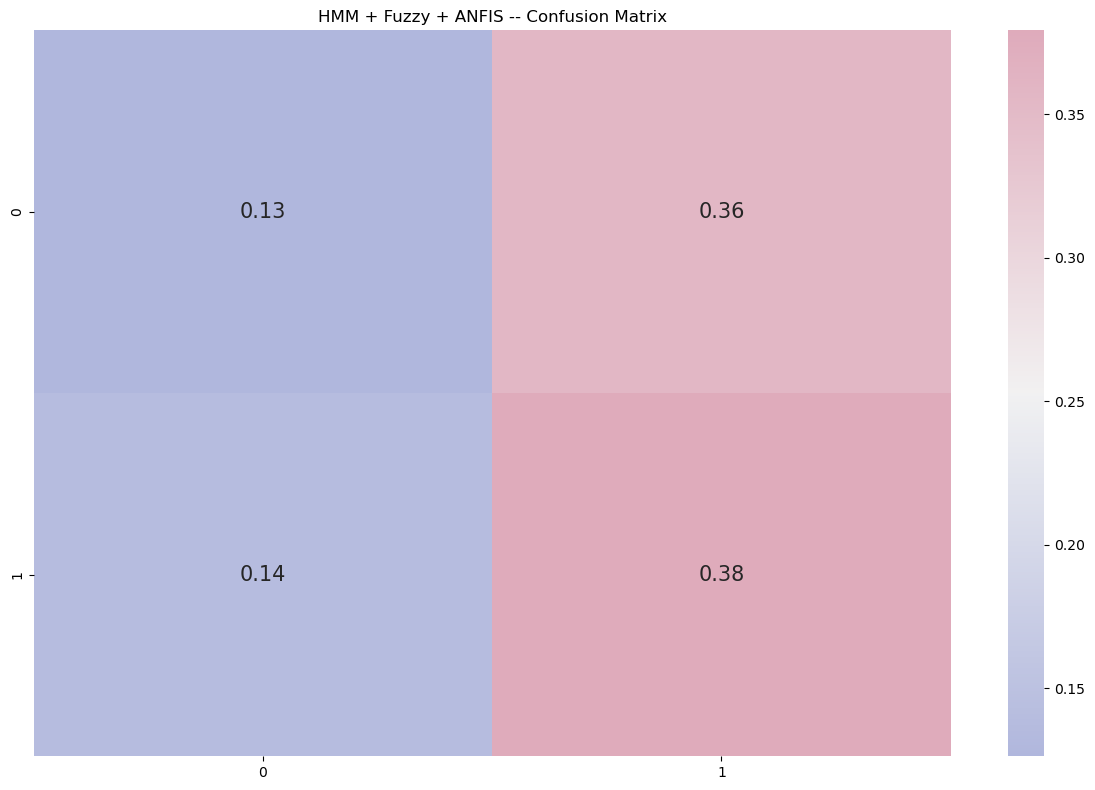

In [342]:
close_prev = np.concatenate([[test_close[0]], actual_close[:-1]])
y_true_dir = (actual_close > close_prev).astype(int)
y_pred_dir = (pred_close  > close_prev).astype(int)

cmap1 = sns.diverging_palette(260, -10, s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12, 8))
cf_matrix = confusion_matrix(y_true_dir, y_pred_dir)
sns.heatmap(cf_matrix / np.sum(cf_matrix), cmap=cmap1, annot=True, annot_kws={'size': 15})
plt.title('HMM + Fuzzy + ANFIS -- Confusion Matrix')
plt.tight_layout()
plt.show()


In [343]:
report = classification_report(y_true_dir, y_pred_dir, output_dict=True)
df_report = pd.DataFrame(report).T
df_report['support'] = df_report['support'].astype(int)
df_report[['precision','recall','f1-score','support']].round(2).style\
    .background_gradient(cmap='Blues', subset=['precision','recall','f1-score'])\
    .format({'precision':'{:.2f}','recall':'{:.2f}','f1-score':'{:.2f}','support':'{:d}'})


,precision,recall,f1-score,support
0,0.48,0.26,0.34,130
1,0.52,0.73,0.61,139
accuracy,0.51,0.51,0.51,0
macro avg,0.50,0.50,0.47,269
weighted avg,0.50,0.51,0.48,269


## 10. Visualisation

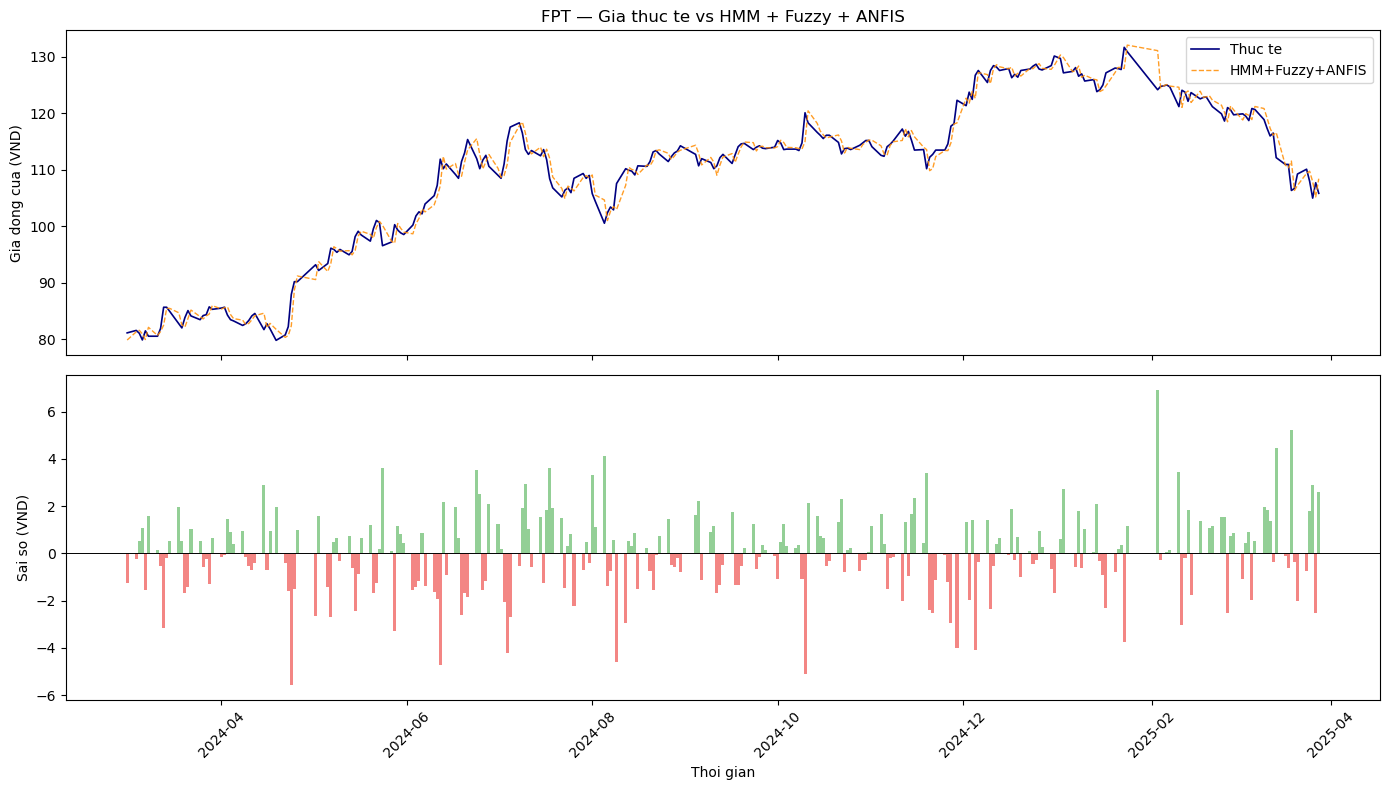

In [344]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(pred_dates, actual_close, label='Thuc te',      color='navy',   linewidth=1.2)
axes[0].plot(pred_dates, pred_close,   label='HMM+Fuzzy+ANFIS', color='darkorange', linewidth=1.0, alpha=0.85, linestyle='--')
axes[0].set_ylabel('Gia dong cua (VND)')
axes[0].set_title('FPT — Gia thuc te vs HMM + Fuzzy + ANFIS')
axes[0].legend()

error = pred_close - actual_close
axes[1].bar(pred_dates, error, color=['#EF5350' if e < 0 else '#66BB6A' for e in error], alpha=0.7, width=1)
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].set_ylabel('Sai so (VND)')
axes[1].set_xlabel('Thoi gian')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('hmm_fuzzy_anfis_prediction.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Diễn giải Fuzzy Rules

Mỗi rule tương ứng với 1 chế độ thị trường (bucket log-likelihood).  
**μ_k** = mức log-likelihood trung bình của bucket (càng gần 0 = thị trường càng "bình thường")  
**σ_k** = độ biến động trong bucket


In [345]:
print('Fuzzy Rules sau ANFIS optimization (consequence predict RETURN):')
print(f'{"Rule":>4} {"mu":>8} {"sigma":>6} {"n":>5}  Δopen     Δhigh     Δlow      return    vol_r     bias')
print('-'*90)
for k, r in enumerate(rules):
    p = r['params']
    print(f'  {k:2d}  {r["mu"]:7.2f} {r["sigma"]:6.3f} {r["n_windows"]:5d}  '
          + '  '.join(f'{v:+.5f}' for v in p))

print()
print('Note: params unit = return fraction (e.g. 0.001 = 0.1% per unit feature)')

Fuzzy Rules sau ANFIS optimization (consequence predict RETURN):
Rule       mu  sigma     n  Δopen     Δhigh     Δlow      return    vol_r     bias
------------------------------------------------------------------------------------------
   0   -14.13  0.489    30  -0.15731  +0.73996  -0.17116  +0.16926  -0.01618  -0.01311
   1   -12.40  0.471    84  -0.27869  +0.29659  +0.31857  +0.13285  -0.00119  +0.00118
   2   -10.69  0.554   177  -0.32384  +0.18885  +0.41653  -0.05775  +0.00660  +0.00207
   3    -8.95  0.518   282  -0.32277  +0.16007  -0.06405  -0.17961  -0.00138  -0.00172
   4    -7.21  0.517   299  -0.00807  +0.25422  -0.04581  +0.06837  -0.00150  -0.00017
   5    -5.49  0.614   203  +0.00236  +0.02513  +0.03908  -0.00465  +0.00187  +0.00174

Note: params unit = return fraction (e.g. 0.001 = 0.1% per unit feature)


## 12. Membership Functions — Phân phối Gaussian mỗi Rule

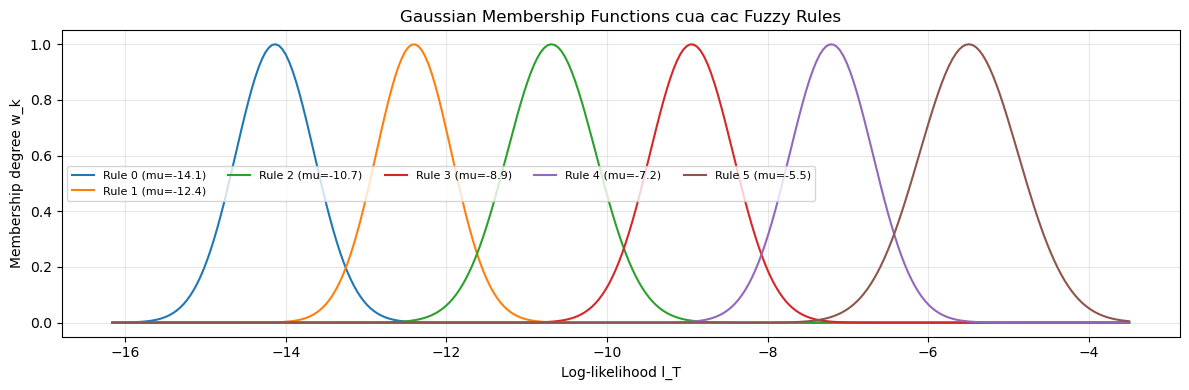

In [346]:
ll_range = np.linspace(win_ll.min() - 1, win_ll.max() + 1, 300)
fig, ax = plt.subplots(figsize=(12, 4))

cmap = plt.cm.tab10
for k, r in enumerate(rules):
    w = gaussian_weight(ll_range, r['mu'], r['sigma'])
    ax.plot(ll_range, w, label=f'Rule {k} (mu={r["mu"]:.1f})', color=cmap(k % 10))

ax.set_xlabel('Log-likelihood l_T')
ax.set_ylabel('Membership degree w_k')
ax.set_title('Gaussian Membership Functions cua cac Fuzzy Rules')
ax.legend(fontsize=8, ncol=min(5, len(rules)))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hmm_fuzzy_membership.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. ANN — Mạng nơ-ron nhân tạo

Dùng **ANN hồi quy** (regression) dự đoán giá đóng cửa ngày mai từ dữ liệu OHLCV cơ bản.  
Split ngẫu nhiên 80/20 (`random_state=42`), scale riêng features và target để inverse transform chính xác.

| Thông số | Giá trị |
|----------|---------|
| Input | 6 features: open, high, low, close, volume, return |
| Architecture | 32 → 32 → 16 → Dropout(0.25) → 8 → Dropout(0.5) → 1 |
| Optimizer | Adam (lr = 0.001) |
| Loss | MSE |
| Early Stopping | patience=20, min_delta=0.0001 |

In [347]:
from sklearn.preprocessing import StandardScaler as SS
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from keras import callbacks as keras_cb

ann_df = df[['time','open','high','low','close','volume','return']].copy()
ann_df['CloseNextDay'] = ann_df['close'].shift(-1)
ann_df = ann_df.dropna().reset_index(drop=True)

ANN_FEATS = ['open','high','low','close','volume','return']

X_all     = ann_df[ANN_FEATS].values
y_all     = ann_df['CloseNextDay'].values
dates_all = ann_df['time'].values

X_ann_tr, X_ann_te, y_ann_tr, y_ann_te, dates_tr, dates_te = train_test_split(
    X_all, y_all, dates_all, test_size=0.2, random_state=42
)

feat_sc = SS(); tgt_sc = SS()
X_ann_tr_s = feat_sc.fit_transform(X_ann_tr)
X_ann_te_s = feat_sc.transform(X_ann_te)
y_ann_tr_s = tgt_sc.fit_transform(y_ann_tr.reshape(-1,1)).flatten()

sort_idx       = np.argsort(dates_te)
ann_test_dates = pd.to_datetime(dates_te[sort_idx])
X_ann_te_s     = X_ann_te_s[sort_idx]
y_ann_te       = y_ann_te[sort_idx]

print(f'ANN train: {X_ann_tr_s.shape} | test: {X_ann_te_s.shape}')

ann = Sequential([
    Dense(32, kernel_initializer='uniform', activation='relu', input_dim=len(ANN_FEATS)),
    Dense(32, kernel_initializer='uniform', activation='relu'),
    Dense(16, kernel_initializer='uniform', activation='relu'),
    Dropout(0.25),
    Dense(8,  kernel_initializer='uniform', activation='relu'),
    Dropout(0.5),
    Dense(1,  kernel_initializer='uniform', activation='linear'),
])
ann.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

es = keras_cb.EarlyStopping(min_delta=0.0001, patience=20, restore_best_weights=True)

print('Training ANN...')
ann.fit(X_ann_tr_s, y_ann_tr_s, batch_size=32, epochs=150,
        validation_split=0.2, callbacks=[es], verbose=0)
print(f'Done. Epochs: {len(ann.history.history["loss"])}')

ANN train: (1079, 6) | test: (270, 6)
Training ANN...
Done. Epochs: 46


In [348]:
y_ann_pred_s = ann.predict(X_ann_te_s, verbose=0).flatten()
ann_pred_close = tgt_sc.inverse_transform(y_ann_pred_s.reshape(-1,1)).flatten()
ann_true_close = y_ann_te  # gia thuc te (chua scale)
print(f'ANN test: {len(ann_pred_close)} predictions')
print(f'Sample — Actual: {ann_true_close[0]:.2f}  Predicted: {ann_pred_close[0]:.2f}')


ANN test: 270 predictions
Sample — Actual: 19.83  Predicted: 28.59


In [349]:
# Baseline HMM: log-likelihood similarity (tu fpt_stock_price_prediction_hmm.ipynb)
# Reuse win_ll va windows_ret_next da co san
N_SIMILAR = 5

hmm_base_pred = []
print('Computing HMM baseline predictions...')
for i in range(len(test_df) - 1):
    idx = test_start_idx + i
    obs_win = all_obs[idx - WINDOW_SIZE + 1 : idx + 1]
    if len(obs_win) < WINDOW_SIZE:
        continue
    L_T      = model.log_likelihood(obs_win)
    distances = (win_ll - L_T) ** 2
    top_idx  = np.argsort(distances)[:N_SIMILAR]
    ret_hat  = windows_ret_next[top_idx].mean()
    hmm_base_pred.append(all_close[idx] * (1 + ret_hat))

hmm_base_pred = np.array(hmm_base_pred)
print(f'HMM baseline: {len(hmm_base_pred)} predictions')


Computing HMM baseline predictions...
HMM baseline: 269 predictions


## 14. So sánh tổng hợp — 3 mô hình

| Mô hình | Phương pháp | Đặc điểm |
|---------|-------------|----------|
| **HMM Baseline** | Log-likelihood similarity — tìm K windows train gần nhất | Không learning, pure retrieval |
| **HMM + ANFIS** | Fuzzy rules Takagi-Sugeno + hybrid LSE/GD | Học theo regime thị trường |
| **ANN** | Mạng nơ-ron hồi quy trên OHLCV | End-to-end, không cần feature engineering |

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_reg(y_true, y_pred, ref_close):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)
    prev = np.concatenate([[ref_close], y_true[:-1]])
    dir_acc = (np.sign(y_true - prev) == np.sign(y_pred - prev)).mean() * 100
    return {'MAE (VND)': mae, 'RMSE (VND)': rmse,
            'MAPE (%)': mape, 'R²': r2, 'Dir Acc (%)': dir_acc}

df_cmp = pd.DataFrame({
    'HMM (Baseline)':      eval_reg(actual_close,   hmm_base_pred,  test_close[0]),
    'HMM + Fuzzy + ANFIS': eval_reg(actual_close,   pred_close,     test_close[0]),
    'ANN':                 eval_reg(ann_true_close,  ann_pred_close, ann_true_close[0]),
}).T

df_cmp.round(4).style\
    .background_gradient(cmap='Blues',  subset=['R²', 'Dir Acc (%)'])\
    .background_gradient(cmap='Reds_r', subset=['MAE (VND)', 'RMSE (VND)', 'MAPE (%)'])\
    .format({'MAE (VND)':'{:.4f}','RMSE (VND)':'{:.4f}',
             'MAPE (%)':'{:.2f}','R²':'{:.4f}','Dir Acc (%)':'{:.1f}'})


,MAE (VND),RMSE (VND),MAPE (%),R²,Dir Acc (%)
HMM (Baseline),1.4630,1.9218,1.35,0.9802,52.0
HMM + Fuzzy + ANFIS,1.3017,1.7225,1.20,0.9841,49.1
ANN,4.0641,5.3642,11.93,0.9692,62.2


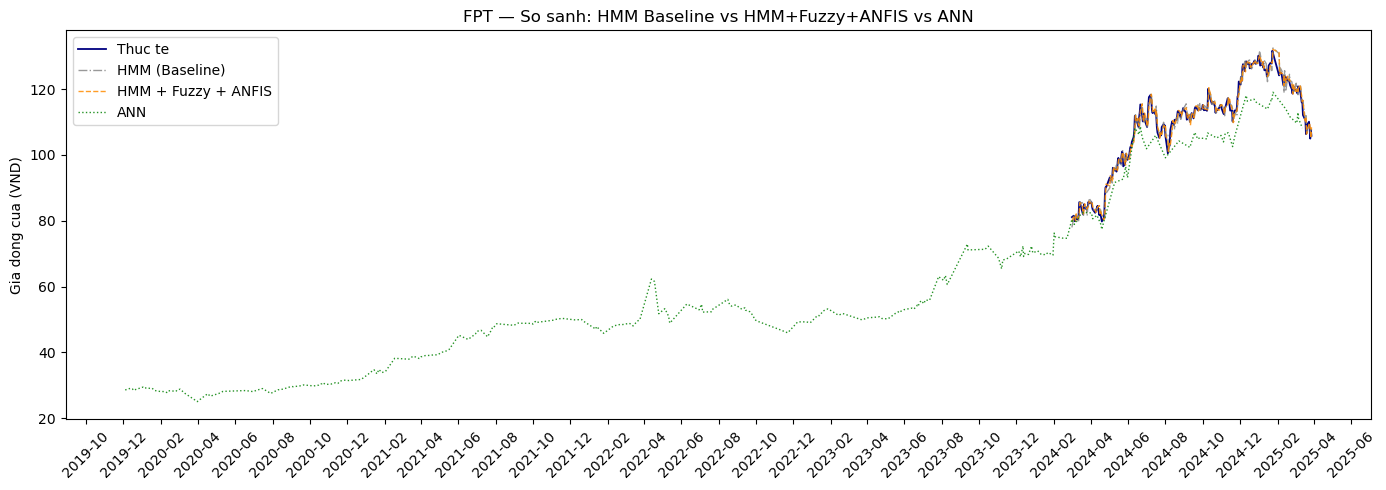

In [351]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pred_dates,      actual_close,   label='Thuc te',             color='navy',      linewidth=1.3)
ax.plot(pred_dates,      hmm_base_pred,  label='HMM (Baseline)',      color='gray',      linewidth=1.0, linestyle='-.',  alpha=0.8)
ax.plot(pred_dates,      pred_close,     label='HMM + Fuzzy + ANFIS', color='darkorange',linewidth=1.0, linestyle='--',  alpha=0.85)
ax.plot(ann_test_dates,  ann_pred_close, label='ANN',                 color='green',     linewidth=1.0, linestyle=':',   alpha=0.85)
ax.set_ylabel('Gia dong cua (VND)')
ax.set_title('FPT — So sanh: HMM Baseline vs HMM+Fuzzy+ANFIS vs ANN')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()